In [1]:
import numpy as np
import matplotlib.pyplot as plt
import utm
import open3d as o3d
from pyproj import Transformer

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import utm

# Note: open3d is imported only in the advanced_seabed_processing function


def clean_iqr(data, iqr_factor=3.0):
    """
    Remove outliers from data using the IQR method.

    Parameters:
      data (np.ndarray): 2D array of shape (N, 3)
      iqr_factor (float): Factor to define the acceptable range (default 3.0)

    Returns:
      np.ndarray: The cleaned data.
    """
    filtered = data
    for col in range(filtered.shape[1]):
        q1 = np.percentile(filtered[:, col], 25)
        q3 = np.percentile(filtered[:, col], 75)
        iqr = q3 - q1
        lower = q1 - iqr_factor * iqr
        upper = q3 + iqr_factor * iqr
        mask = (filtered[:, col] >= lower) & (filtered[:, col] <= upper)
        filtered = filtered[mask]
    return filtered


def plot_xyz(data=None, title=None, filename=None):
    """
    Plot a 3D scatter of the provided data with the given title.
    The plot is static (rotation disabled).

    If a filename is provided, the function will load the data from the file,
    clean it using the clean_iqr function, and then plot it.

    Parameters:
      data (np.ndarray): 2D array with columns [X, Y, Z]. Default is None.
      title (str): Title for the plot. If None and filename is provided, a default title is set.
      filename (str): Path to the .xyz file. If provided, data is loaded from this file.
    """
    if filename is not None:
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return
        data = clean_iqr(data)
        if title is None:
            title = f"3D Scatter Plot ({len(data):,} points)"
    elif data is None:
        print("No data provided. Please supply either a data array or a filename.")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    # Disable interactive navigation (rotation/zoom)
    ax.set_navigate(False)
    sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=data[:, 2], s=1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.invert_zaxis()
    if title:
        ax.set_title(title)
    plt.colorbar(sc, label="Elevation")
    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt


def plot_xy(data=None, title=None, filename=None):
    """
    Plot a 2D scatter of the provided data with the given title.
    The plot is static.

    If a filename is provided, the function will load the data from the file,
    clean it using the clean_iqr function, and then plot it.

    Parameters:
      data (np.ndarray): 2D array with columns [X, Y, Z]. Only X and Y will be plotted.
      title (str): Title for the plot. If None and filename is provided, a default title is set.
      filename (str): Path to the .xyz file. If provided, data is loaded from this file.
    """
    # Load data from file if provided
    if filename is not None:
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return
        data = clean_iqr(data)
        if title is None:
            title = f"2D Scatter Plot ({len(data):,} points)"
    elif data is None:
        print("No data provided. Please supply either a data array or a filename.")
        return

    # Create the figure and axis for the 2D plot
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot the X and Y columns only. Color is mapped to the Y value for simplicity.
    sc = ax.scatter(data[:, 0], data[:, 1], c=data[:, 1], s=1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    if title:
        ax.set_title(title)

    plt.colorbar(sc, label="Y value")
    plt.tight_layout()
    plt.show()


def plot_xyz_in_chunks(data=None, filename=None, chunk_size=1_000_000):
    """
    Load or accept in‑memory XYZ data, clean it, and plot it in chunks.
    Each chunk is plotted using a static 3D scatter plot.

    Parameters:
      data (np.ndarray, optional): Nx3 array of [X, Y, Z] points.
      filename (str, optional): Path to a .xyz file. Ignored if `data` is provided.
      chunk_size (int): Number of points per chunk.
    """
    if data is None:
        if filename is None:
            print("Error: Must supply either `data` or `filename`.")
            return
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return

    total = data.shape[0]
    for start in range(0, total, chunk_size):
        stop = min(start + chunk_size, total)
        subset = data[start:stop]
        subset = clean_iqr(subset)
        if subset.size == 0:
            print(f"Chunk {start:,}–{stop:,} empty after cleaning; skipping.")
            continue

        title = f"Points {start:,}–{stop:,} of {total:,}"
        plot_xyz(data=subset, title=title)


def plot_xyz_slices(data=None, filename=None, n_slices=2, iqr_factor=3.0):
    """
    Split the data into n_slices and plot each slice as a static 3D scatter plot.
    Each plot has interactive rotation disabled.

    Parameters:
      data (np.ndarray): 2D array with columns [X, Y, Z].
      filename (str, optional): If provided, the data is loaded from this file.
      n_slices (int): Number of slices to split the data into.
      iqr_factor (float): Factor for the IQR-based outlier cleaning.
    """
    if filename:
        data = np.loadtxt(filename)
    if data is None:
        raise ValueError("Provide either `data` or `filename`.")

    data = clean_iqr(data, iqr_factor=iqr_factor)
    total = data.shape[0]
    slice_size = total // n_slices

    for i in range(n_slices):
        start = i * slice_size
        stop = total if i == n_slices - 1 else (i + 1) * slice_size
        subset = data[start:stop]
        if subset.size == 0:
            continue

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        # Disable interactive navigation for a static view
        ax.set_navigate(False)
        sc = ax.scatter(subset[:, 0], subset[:, 1], subset[:, 2], c=subset[:, 2], s=1)
        ax.set_title(f"Slice {i+1}/{n_slices}: points {start:,}–{stop:,}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.invert_zaxis()
        plt.colorbar(sc, label="Elevation")
        plt.tight_layout()
        plt.show()


def advanced_seabed_processing(
    filename=None,
    data=None,
    voxel_size=0.05,
    nb_neighbors=20,
    std_ratio=2.0,
    plane_distance_threshold=0.03,
):
    """
    Process seabed point cloud data to separate the seabed from anomalies.

    Either a filename or a data array (or an Open3D PointCloud) must be provided.

    Parameters:
      filename (str): Path to the .xyz file. Optional if data is provided.
      data: Either an Open3D PointCloud or a NumPy array with shape (N, 3). Optional if filename is provided.
      voxel_size (float): Voxel size for downsampling.
      nb_neighbors (int): Number of neighbors for statistical outlier removal.
      std_ratio (float): Standard deviation ratio for outlier removal.
      plane_distance_threshold (float): Distance threshold for plane segmentation.

    Returns:
      seabed (o3d.geometry.PointCloud): The points belonging to the seabed.
      anomalies (o3d.geometry.PointCloud): The points that are not part of the seabed.
      plane_model (list of float): The coefficients of the fitted plane.
    """
    import open3d as o3d

    if data is not None:
        if isinstance(data, o3d.geometry.PointCloud):
            pcd = data
        else:
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(data)
    elif filename is not None:
        pcd = o3d.io.read_point_cloud(filename)
    else:
        raise ValueError("Either a filename or data must be provided.")

    # 1. Voxel downsample (reduce density while preserving geometry)
    pcd = pcd.voxel_down_sample(voxel_size)

    # 2. Statistical Outlier Removal (remove isolated noise)
    pcd, _ = pcd.remove_statistical_outlier(
        nb_neighbors=nb_neighbors, std_ratio=std_ratio
    )

    # 3. Estimate normals (required for plane segmentation and smoothing)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=voxel_size * 2, max_nn=30
        )
    )

    # 4. Plane segmentation to approximate the seabed
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=plane_distance_threshold, ransac_n=3, num_iterations=1000
    )
    seabed = pcd.select_by_index(inliers)
    anomalies = pcd.select_by_index(inliers, invert=True)

    return seabed, anomalies, plane_model


def load_xyz_interval(source, start_index, end_index):
    """
    Load a subset of an .xyz file or a NumPy array given a starting and ending index.

    Parameters:
      source (str or np.ndarray): If a string, it is interpreted as the path to an .xyz file.
                                  If a NumPy array, it is assumed to be of shape (N, 3).
      start_index (int): The line number (0-based) of the first point to load.
      end_index (int): The line number (0-based, exclusive) of the last point to load.

    Returns:
      np.ndarray: 2D array of points with columns [X, Y, Z].
    """
    if isinstance(source, str):
        nrows = end_index - start_index
        data = np.loadtxt(source, skiprows=start_index, max_rows=nrows)
    elif isinstance(source, np.ndarray):
        data = source[start_index:end_index]
    else:
        raise ValueError("source must be either a filename (str) or a NumPy array")
    return data


def lat_long_2_utm(lat, lon, handle_mixed_signed_latitude_as_postive=False):
    """
    Converts from latitude, longitude (WGS84) to UTM.

    Returns (easting, northing, zoneNumber, zoneLetter).
    """
    is_numpy = lambda x: type(x).__module__ == np.__name__
    if is_numpy(lat) or is_numpy(lon):
        if lat.size == 0 or lon.size == 0:
            return np.empty(0), np.empty(0), 0, 0

    if handle_mixed_signed_latitude_as_postive:
        sign = np.sign(lat)
        if not (np.all(sign >= 0) or np.all(sign < 0)):
            lat = np.abs(lat)

    easting, northing, zoneNumber, zoneLetter = utm.from_latlon(lat, lon)
    return easting, northing, zoneNumber, zoneLetter


def convert_local_utm(xyz_data, origin):
    """
    Convert a .xyz array to local UTM coordinates relative to the given origin.
    """
    origin_lat, origin_lon = origin
    east_origin, north_origin, zone_num, zone_letter = lat_long_2_utm(
        origin_lat, origin_lon
    )

    file_easting = xyz_data[:, 0]
    file_northing = xyz_data[:, 1]

    data_lat, data_lon = utm.to_latlon(file_easting, file_northing, 33, "N")
    corrected_east, corrected_north, _, _ = lat_long_2_utm(data_lat, data_lon)

    local_east = corrected_east - east_origin
    local_north = corrected_north - north_origin

    local_data = np.column_stack((local_east, local_north, xyz_data[:, 2]))
    return local_data


def plot_origin_and_point(data_local, origin, index=0):
    """
    Create a 2D scatter plot showing the origin and a selected data point.
    The origin is plotted at (0, 0) and the selected point is plotted using its local offsets.
    """
    origin_lat, origin_lon = origin
    east_origin, north_origin, zone_num, zone_letter = lat_long_2_utm(
        origin_lat, origin_lon
    )
    point_local = data_local[index]
    local_east, local_north, _ = point_local
    point_east = east_origin + local_east
    point_north = north_origin + local_north
    data_lat, data_lon = utm.to_latlon(point_east, point_north, zone_num, zone_letter)

    origin_label = (
        f"Origin:\n"
        f"Lat, Lon: ({origin_lat:.6f}, {origin_lon:.6f})\n"
        f"UTM: ({east_origin:.2f}, {north_origin:.2f})\n"
        f"Zone: {zone_num}{zone_letter}"
    )
    point_label = (
        f"Point {index}:\n"
        f"Lat, Lon: ({data_lat:.6f}, {data_lon:.6f})\n"
        f"UTM: ({point_east:.2f}, {point_north:.2f})\n"
        f"Zone: {zone_num}{zone_letter}"
    )

    plt.figure()
    plt.scatter(0, 0, color="red", marker="o", s=100, label=origin_label)
    plt.scatter(
        local_east, local_north, color="blue", marker="x", s=100, label=point_label
    )
    plt.xlabel("Local East (m)")
    plt.ylabel("Local North (m)")
    plt.title("Local Data: Origin and Selected Point")
    plt.legend()
    plt.grid(True)
    plt.show()


def check_utm_values(data):
    """
    Check each row in the data for valid UTM coordinate ranges.
    """
    for row in data:
        easting, northing = row[0], row[1]
        if not (100000 <= easting <= 999999):
            print(f"Invalid easting: {easting}")
        if not (0 <= northing <= 10000000):
            print(f"Invalid northing: {northing}")


def remove_invalid_utm(data):
    """
    Remove rows with invalid UTM values from the data array.

    Assumptions:
      - data is a 2D NumPy array where:
          Column 0: eastings (valid range: 100,000 m to 999,999 m)
          Column 1: northings (valid range: 0 m to 10,000,000 m)

    Parameters:
      data (np.array): Input data array with UTM coordinates.

    Returns:
      np.array: A new array containing only the valid rows.
    """
    valid_mask = (
        (data[:, 0] >= 100000)
        & (data[:, 0] <= 999999)
        & (data[:, 1] >= 0)
        & (data[:, 1] <= 10000000)
    )
    corrected_data = data[valid_mask]
    return corrected_data


def plot_xyz_combined_chunks(data=None, filename=None, chunk_size=1_000_000):
    """
    Load or accept in‑memory XYZ data, clean it in chunks, and plot all data together
    in a single static 3D scatter plot with each chunk marked by a unique index.
    Interactive navigation is disabled.
    """
    if data is None:
        if filename is None:
            print("Error: Must supply either `data` or `filename`.")
            return
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return

    total = data.shape[0]
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    # Disable interactive rotation
    ax.set_navigate(False)
    cmap = plt.cm.get_cmap("tab20")

    for i, start in enumerate(range(0, total, chunk_size)):
        stop = min(start + chunk_size, total)
        subset = data[start:stop]
        subset = clean_iqr(subset)
        if subset.size == 0:
            print(f"Chunk {start:,}–{stop:,} empty after cleaning; skipping.")
            continue

        color = cmap(i % 20)
        ax.scatter(
            subset[:, 0],
            subset[:, 1],
            subset[:, 2],
            color=color,
            s=1,
            label=f"Chunk {i} ({start:,}–{stop:,})",
        )
        center = np.mean(subset, axis=0)
        ax.text(center[0], center[1], center[2], f"{i}", fontsize=12, color="black")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.invert_zaxis()
    ax.set_title("Combined 3D Scatter Plot with Chunk Annotations")
    plt.legend()
    plt.tight_layout()
    plt.show()


def downsample_data(data, skip=4):
    """
    Downsamples the input data by selecting every 'skip'-th point.

    Parameters:
      data (np.ndarray): Input data as an NxM array.
      skip (int): The step interval for downsampling. For example, skip=4 selects every fourth point.

    Returns:
      np.ndarray: Downsampled data array.
    """
    return data[::skip]


def interactive_plot_chunks_angles(data=None, filename=None, chunk_size=1_000_000):
    """
    Load or accept in‑memory XYZ data, clean it in chunks, and provide an interactive widget
    to select a chunk. For the selected chunk, display a 2×2 grid of static 3D scatter plots,
    each from a different preset view angle.

    Parameters:
      data (np.ndarray, optional): Nx3 array of [X, Y, Z] points.
      filename (str, optional): Path to a .xyz file. Ignored if `data` is provided.
      chunk_size (int): Number of points per chunk.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import ipywidgets as widgets
    from IPython.display import display

    # Load data if necessary
    if data is None:
        if filename is None:
            print("Error: Must supply either `data` or `filename`.")
            return
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return

    total = data.shape[0]
    chunk_dict = {}  # Mapping label -> (chunk index, cleaned subset)
    for i, start in enumerate(range(0, total, chunk_size)):
        stop = min(start + chunk_size, total)
        subset = data[start:stop]
        subset = clean_iqr(subset)
        if subset.size == 0:
            print(f"Chunk {start:,}–{stop:,} empty after cleaning; skipping.")
            continue
        label = f"Chunk {i} ({start:,}–{stop:,})"
        chunk_dict[label] = (i, subset)

    if not chunk_dict:
        print("No valid chunks available.")
        return

    def plot_chunk(label):
        i, subset = chunk_dict[label]
        # Define a list of preset view angles: (elevation, azimuth)
        view_angles = [(30, 45), (30, 135), (30, 225), (30, 315)]
        fig = plt.figure(figsize=(12, 8))
        for idx, (elev, azim) in enumerate(view_angles):
            ax = fig.add_subplot(2, 2, idx + 1, projection="3d")
            sc = ax.scatter(
                subset[:, 0], subset[:, 1], subset[:, 2], c=subset[:, 2], s=1
            )
            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f"View {idx+1}: elev={elev}, azim={azim}")
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_zlabel("Z")
            ax.invert_zaxis()
        fig.suptitle(f"Chunk {i} - {label}", fontsize=14)
        plt.tight_layout()
        plt.show()

    dropdown = widgets.Dropdown(
        options=list(chunk_dict.keys()), description="Select Chunk:"
    )
    out = widgets.interactive_output(plot_chunk, {"label": dropdown})
    display(widgets.VBox([dropdown, out]))


def interactive_chunks_checkbox(data=None, filename=None, chunk_size=1_000_000):
    """
    Load or accept in‑memory XYZ data, split it into chunks, and provide a widget
    with checkboxes (multi‑select) so that you can choose which chunks to display
    in a single static 3D scatter plot. Each selected chunk is plotted with its own
    color and label.

    Parameters:
      data (np.ndarray, optional): Nx3 array of [X, Y, Z] points.
      filename (str, optional): Path to a .xyz file (ignored if data is provided).
      chunk_size (int): Number of points per chunk.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import ipywidgets as widgets
    from IPython.display import display

    # Load data if necessary
    if data is None:
        if filename is None:
            print("Error: Must supply either `data` or `filename`.")
            return
        try:
            data = np.loadtxt(filename)
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return

    total = data.shape[0]
    chunk_dict = {}  # Dictionary: label -> cleaned subset (chunk)
    labels = []  # List of labels in display order
    for i, start in enumerate(range(0, total, chunk_size)):
        stop = min(start + chunk_size, total)
        subset = data[start:stop]
        subset = clean_iqr(subset)
        if subset.size == 0:
            print(f"Chunk {start:,}–{stop:,} empty after cleaning; skipping.")
            continue
        label = f"Chunk {i} ({start:,}-{stop:,})"
        chunk_dict[label] = subset
        labels.append(label)

    if not labels:
        print("No valid chunks available after cleaning.")
        return

    # Create a multi-select widget (checkboxes-like behavior) with all chunk labels.
    selector = widgets.SelectMultiple(
        options=labels,
        value=tuple(labels),  # Default: all chunks are selected.
        description="Chunks",
        disabled=False,
        rows=min(10, len(labels)),
    )

    def update_plot(selected):
        # Clear any existing figure
        plt.close("all")
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")
        ax.set_navigate(False)  # Disable interactive rotation
        cmap = plt.cm.get_cmap("tab20")
        for idx, label in enumerate(selected):
            subset = chunk_dict[label]
            color = cmap(idx % 20)
            ax.scatter(
                subset[:, 0], subset[:, 1], subset[:, 2], color=color, s=1, label=label
            )
            center = np.mean(subset, axis=0)
            ax.text(
                center[0], center[1], center[2], f"{label}", fontsize=12, color="black"
            )
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.invert_zaxis()
        ax.set_title("Combined 3D Scatter Plot (Selected Chunks)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Link the widget to the update_plot function.
    out = widgets.interactive_output(update_plot, {"selected": selector})
    display(widgets.VBox([selector, out]))


def save_data_to_file(data, output_path, fmt="%.6f", delimiter=" "):
    try:
        np.savetxt(output_path, data, fmt=fmt, delimiter=delimiter)
        print(f"Data successfully saved to: {output_path}")
    except Exception as e:
        print(f"Error saving data to {output_path}: {e}")

In [ ]:
filename = r"C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\test_georef\Live_20241030-112822.xyz"
data = np.loadtxt(filename)
origin = (60.8011575, 10.7122345)

num_points = data.shape[0]
print(f"There are {num_points} points in the file.")

There are 11015985 points in the file.


# remove unvalid points for local convertion

In [4]:
check_utm_values(data)

Invalid easting: -4.08
Invalid northing: -0.69
Invalid easting: -4.02
Invalid northing: -0.69
Invalid easting: -4.02
Invalid northing: -0.7
Invalid easting: -4.02
Invalid northing: -0.69
Invalid easting: -4.02
Invalid northing: -0.69
Invalid easting: -4.02
Invalid northing: -0.69
Invalid easting: -3.98
Invalid northing: -0.69
Invalid easting: -3.98
Invalid northing: -0.69
Invalid easting: -4.01
Invalid northing: -0.69
Invalid easting: -3.97
Invalid northing: -0.69
Invalid easting: -3.99
Invalid northing: -0.7
Invalid easting: -3.94
Invalid northing: -0.7
Invalid easting: -3.92
Invalid northing: -0.69
Invalid easting: -3.92
Invalid northing: -0.69
Invalid easting: -3.91
Invalid northing: -0.7
Invalid easting: -3.87
Invalid northing: -0.7
Invalid easting: -3.88
Invalid northing: -0.69
Invalid easting: -3.87
Invalid northing: -0.69
Invalid easting: -3.88
Invalid northing: -0.69
Invalid easting: -3.87
Invalid northing: -0.69
Invalid easting: -3.83
Invalid northing: -0.69
Invalid easting: -

In [5]:
corrected_data = remove_invalid_utm(data)
check_utm_values(corrected_data)

In [6]:
data_local = convert_local_utm(corrected_data, origin)

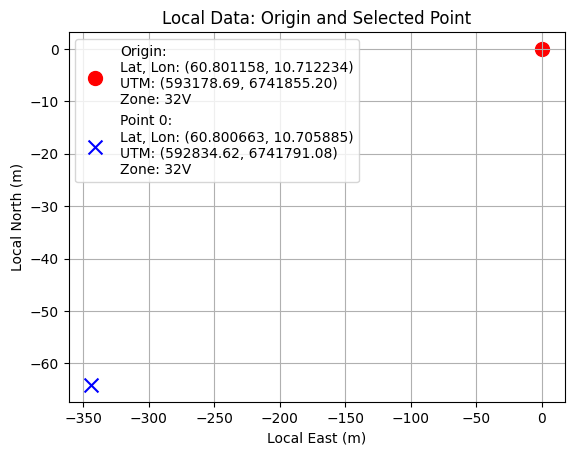

In [7]:
plot_origin_and_point(data_local, index=0, origin=origin)

# plot data


In [19]:
# downsample
downsampled_data = downsample_data(data_local, skip=10)

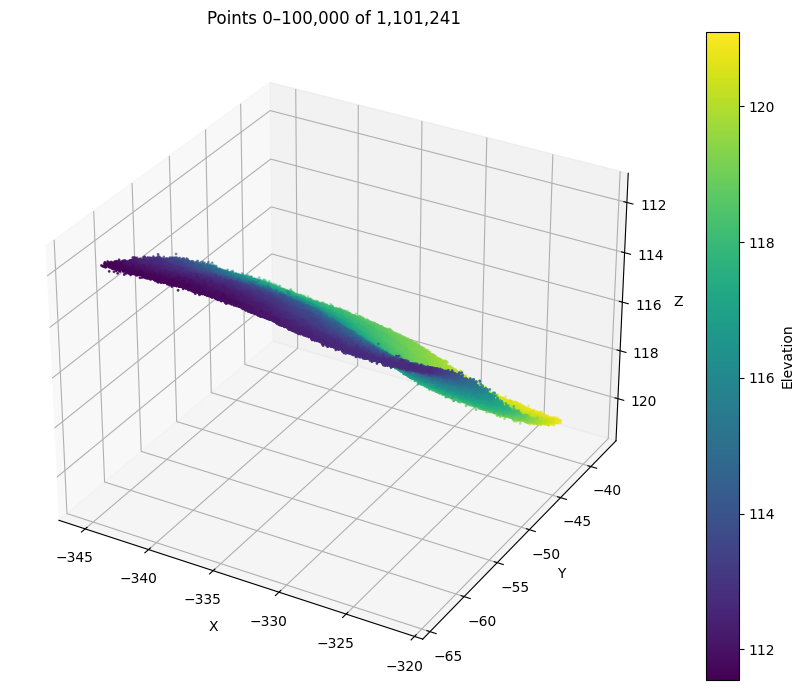

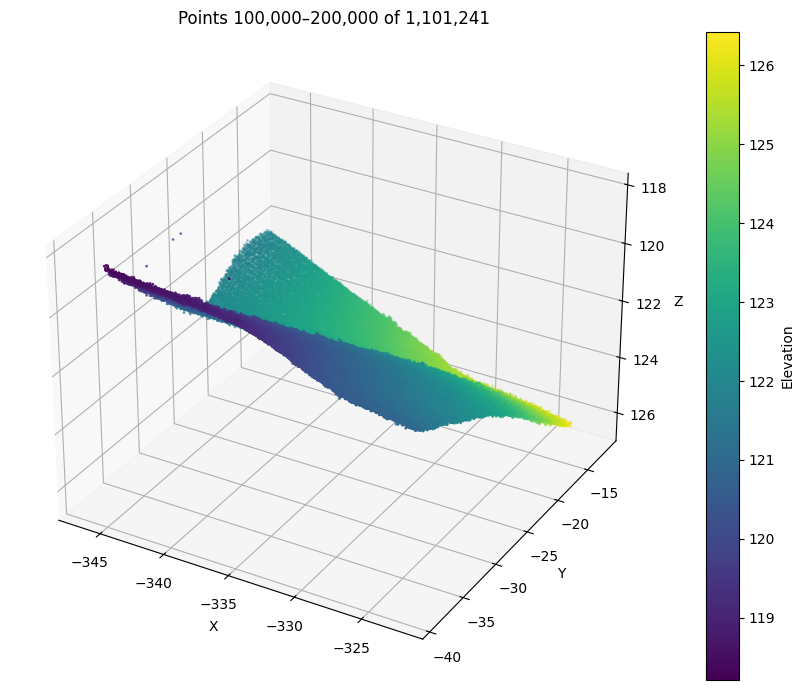

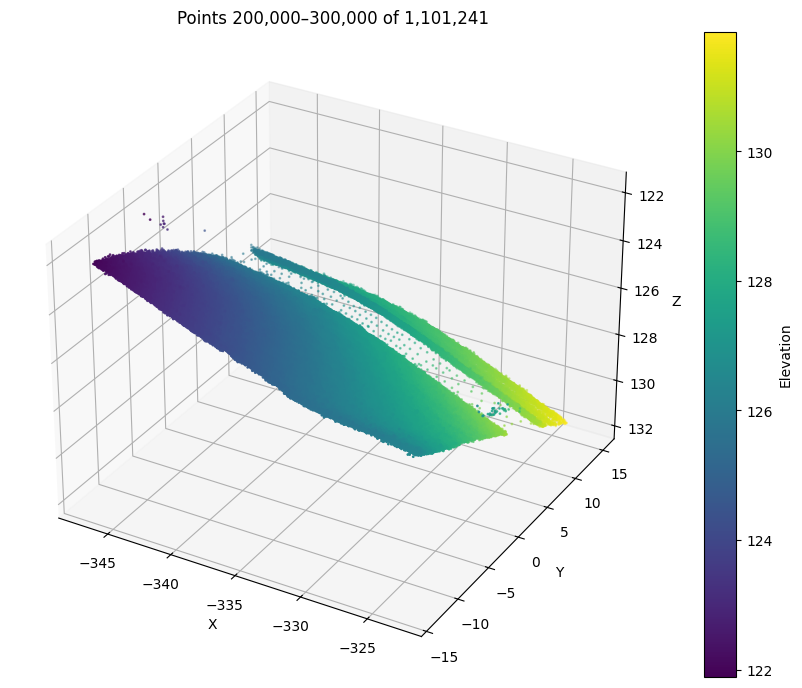

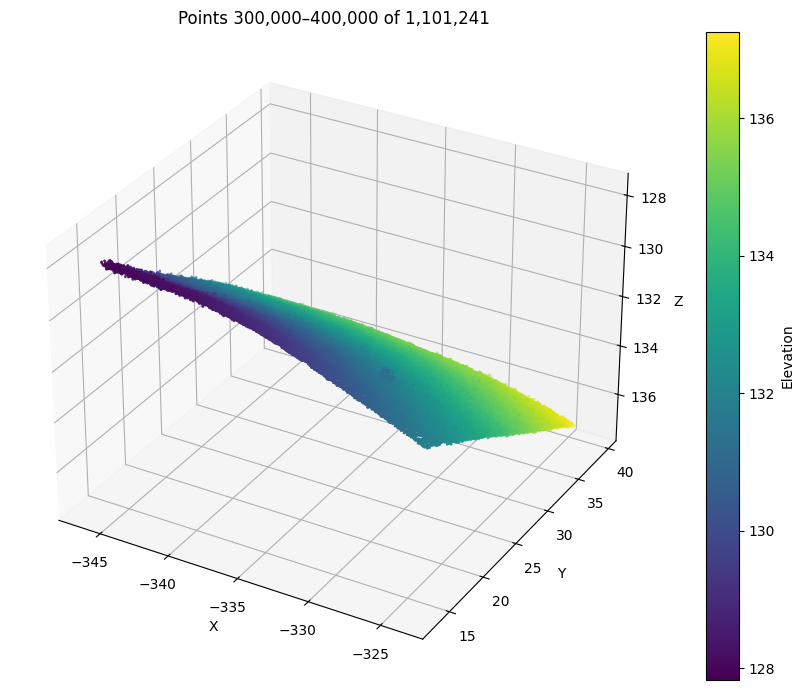

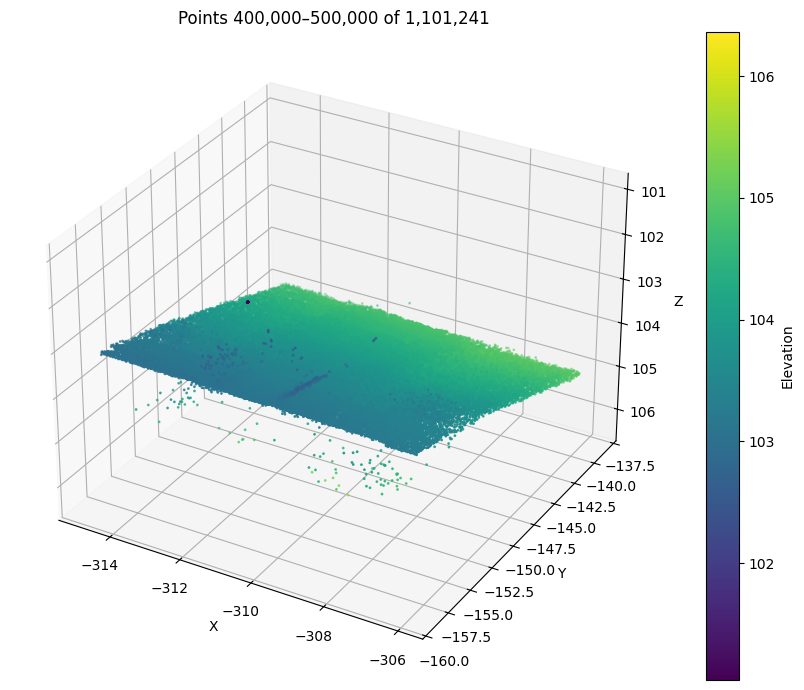

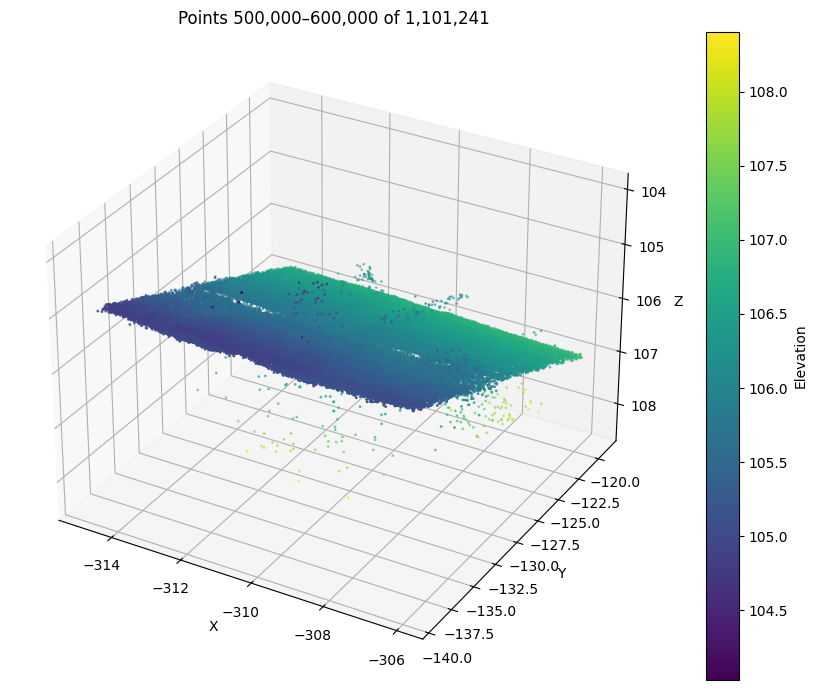

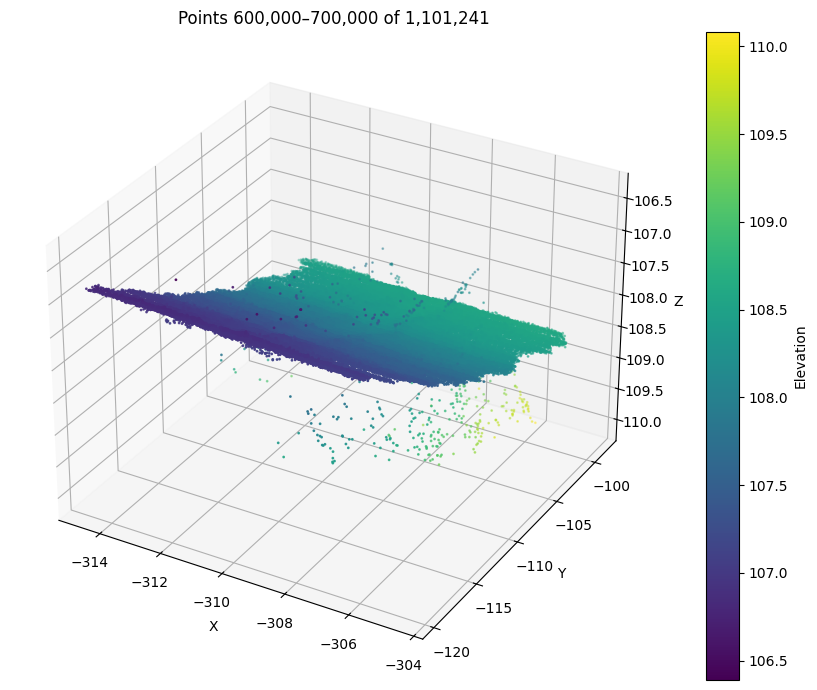

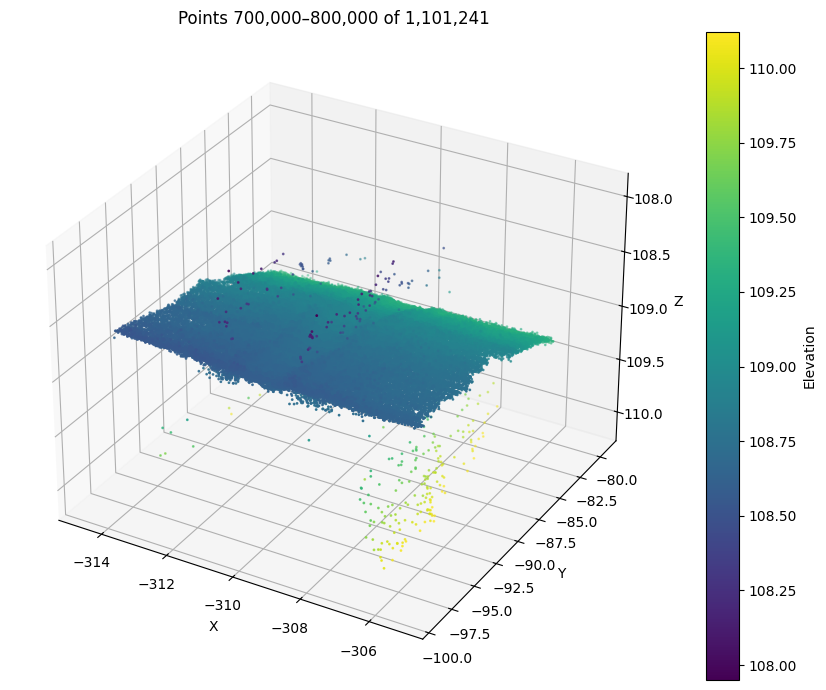

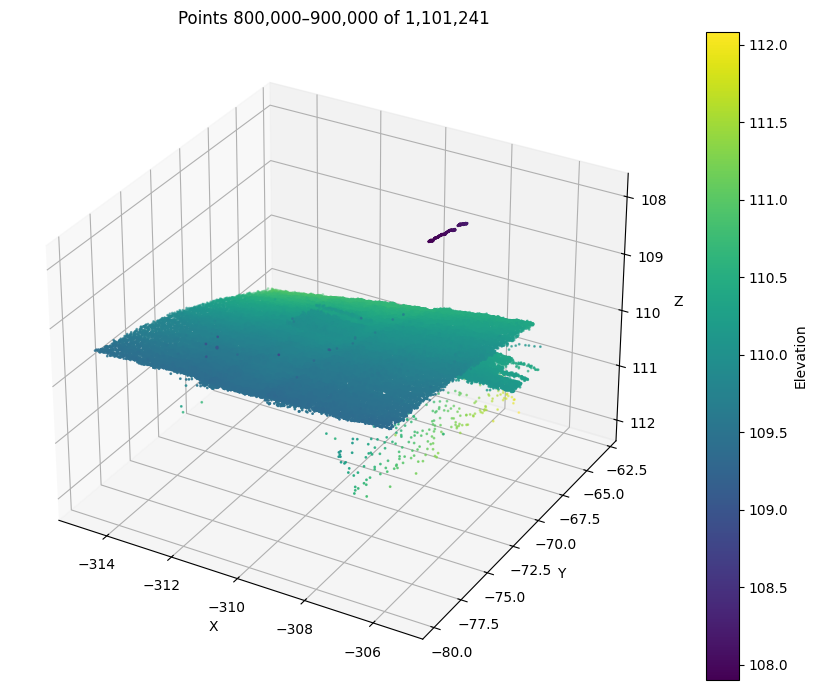

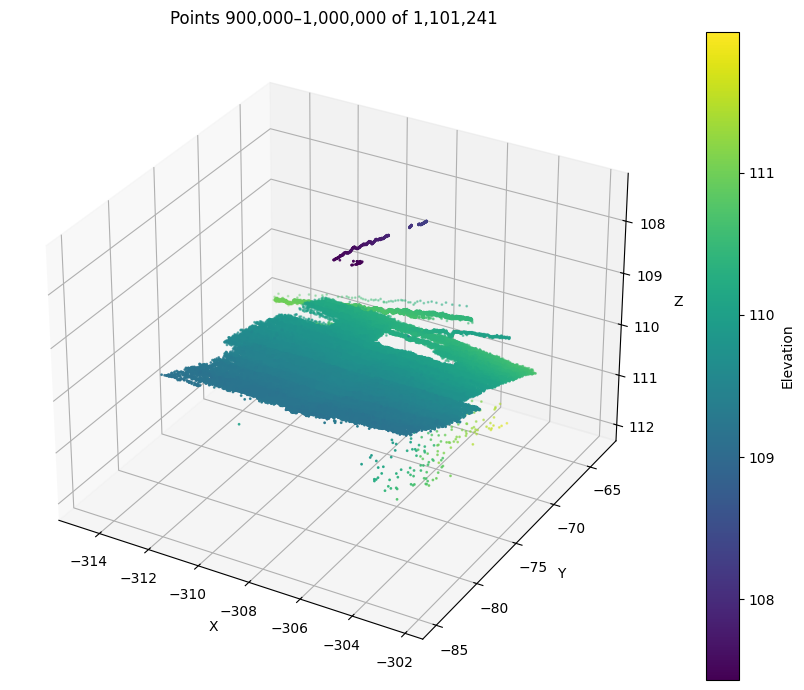

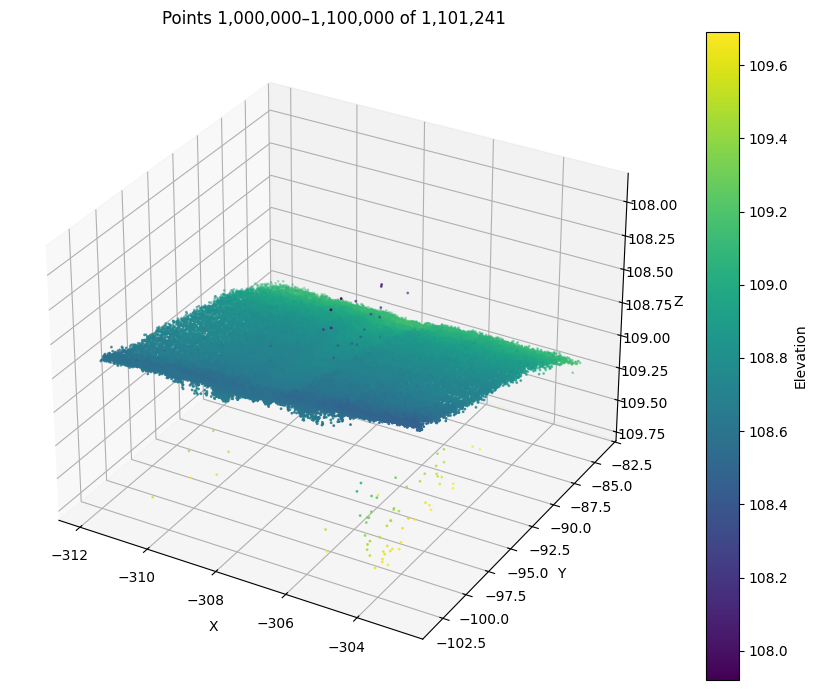

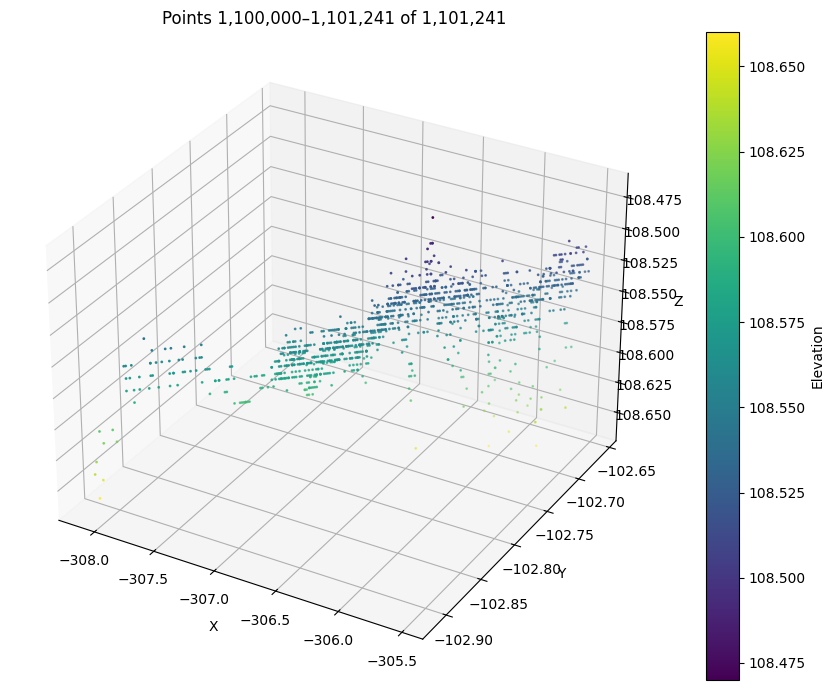

In [21]:
plot_xyz_in_chunks(downsampled_data, chunk_size=100000)

C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_31968\1564115721.py:376: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


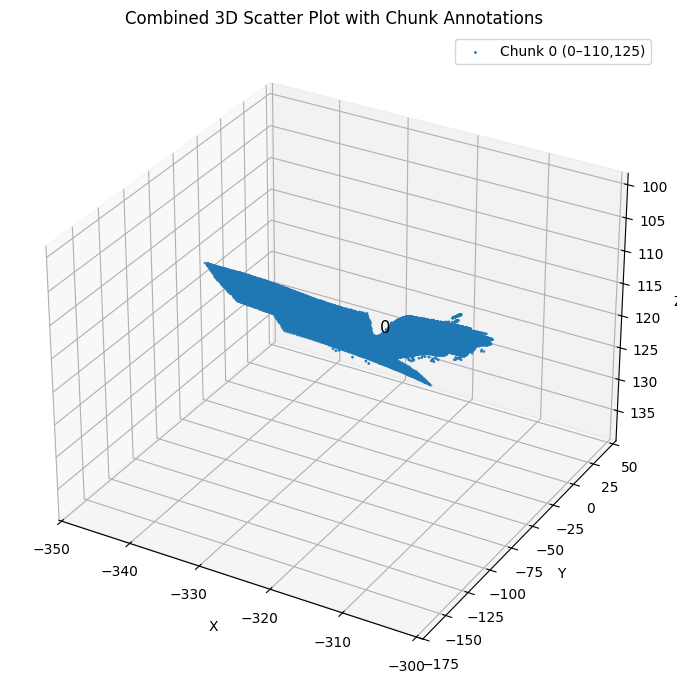

In [ ]:
# plot_xyz_combined_chunks(data_local, chunk_size=1_000_000)
plot_xyz_combined_chunks(downsampled_data, chunk_size=25000)

In [11]:
interactive_plot_chunks_angles(data=downsampled_data, chunk_size=100_000)

In [12]:
interactive_chunks_checkbox(data=downsampled_data, chunk_size=10_000)

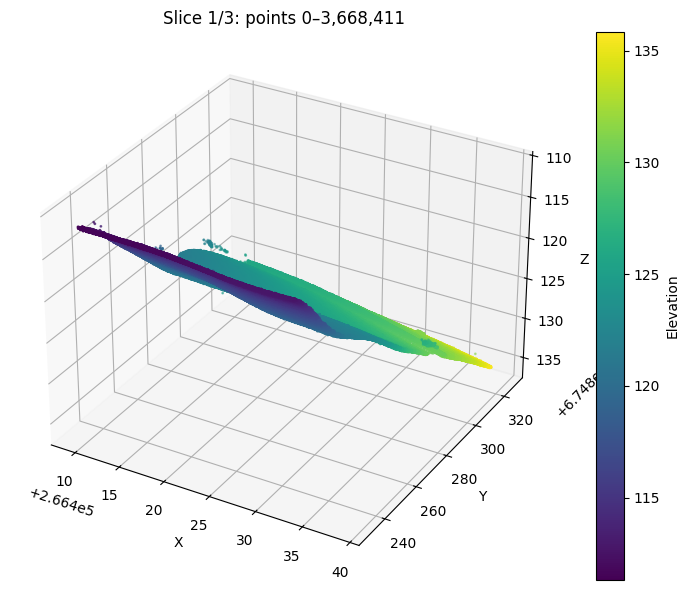

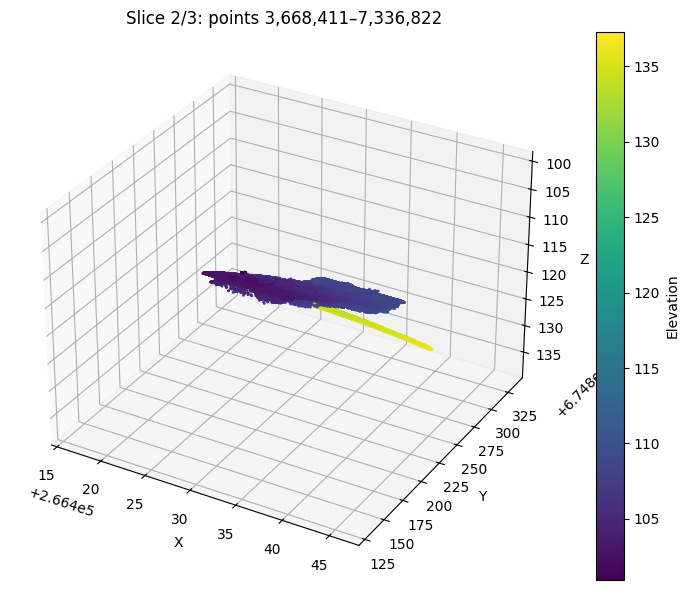

KeyboardInterrupt: 

In [13]:
# some data is hacky, try to find out why the total transect looks weird
plot_xyz_slices(filename=filename, n_slices=3)

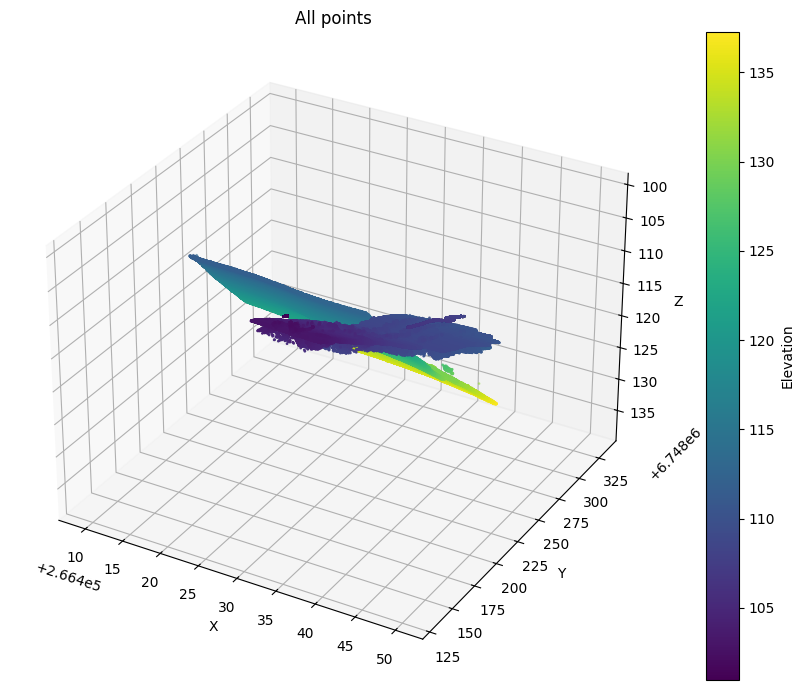

In [ ]:
plot_xyz(filename=filename, title="All points")

# save data to plot in qgis


In [47]:
output_path = r"C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\test_georef\mbes_20k.txt"
# downsampled_data = downsample_data(data, skip=100)
downsampled_data = downsample_data(data_local, skip=100)
# save_data_to_file(data[:1_000_000], output_path)
save_data_to_file(downsampled_data[:20_000], output_path)

Data successfully saved to: C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\test_georef\mbes_20k.txt


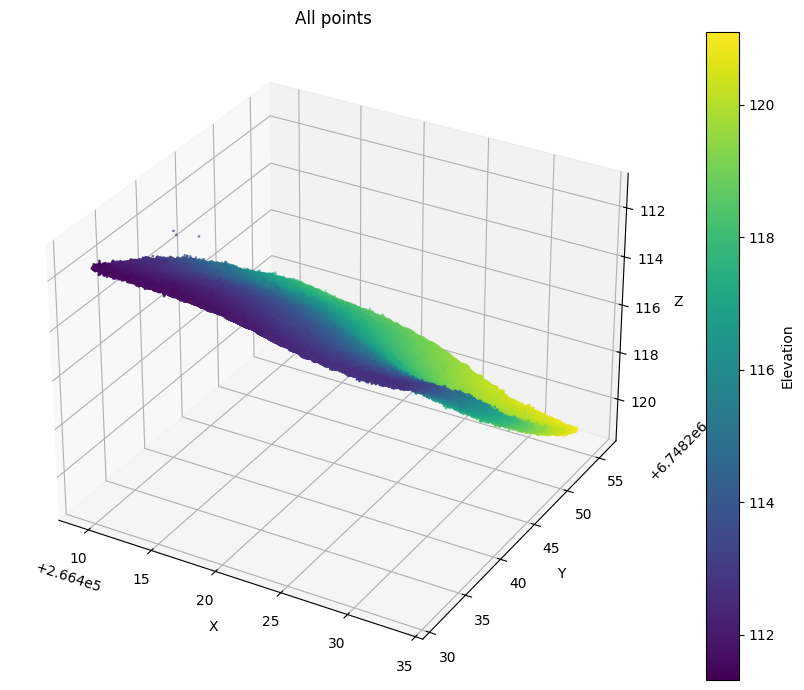

In [ ]:
plot_xyz(data=data[:1_000_000], title="All points")

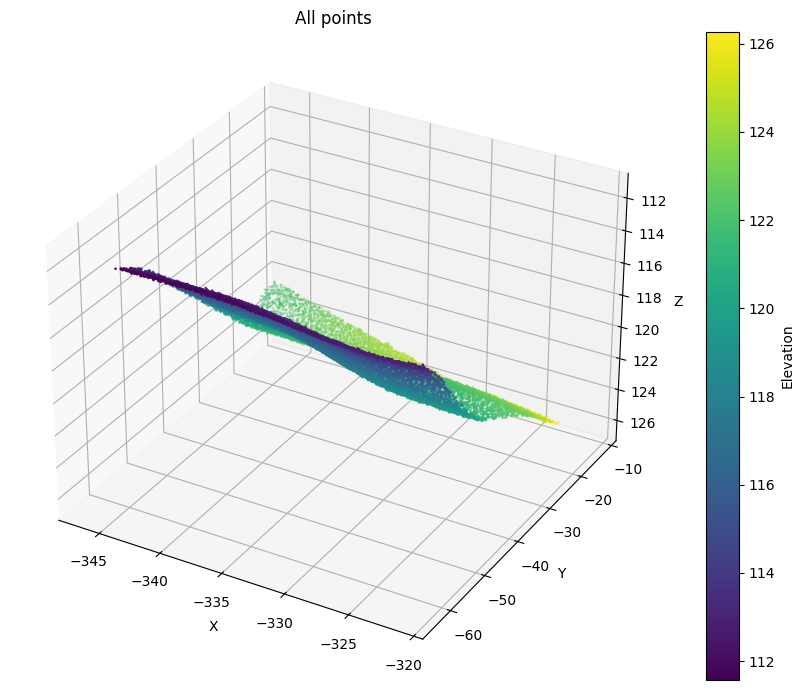

In [45]:
plot_xyz(downsampled_data[:20_000], title="All points")

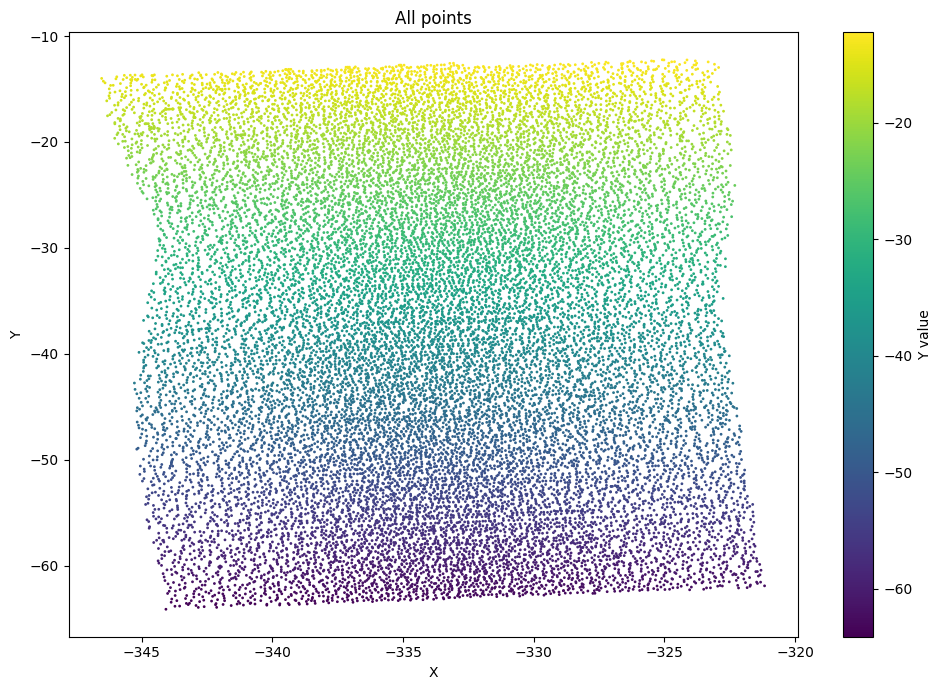

In [46]:
plot_xy(data=downsampled_data[:20_000], title="All points")

# fix the signal problems by sampling, first we fix the local coordinate problem

Loaded 100000 points from the file.


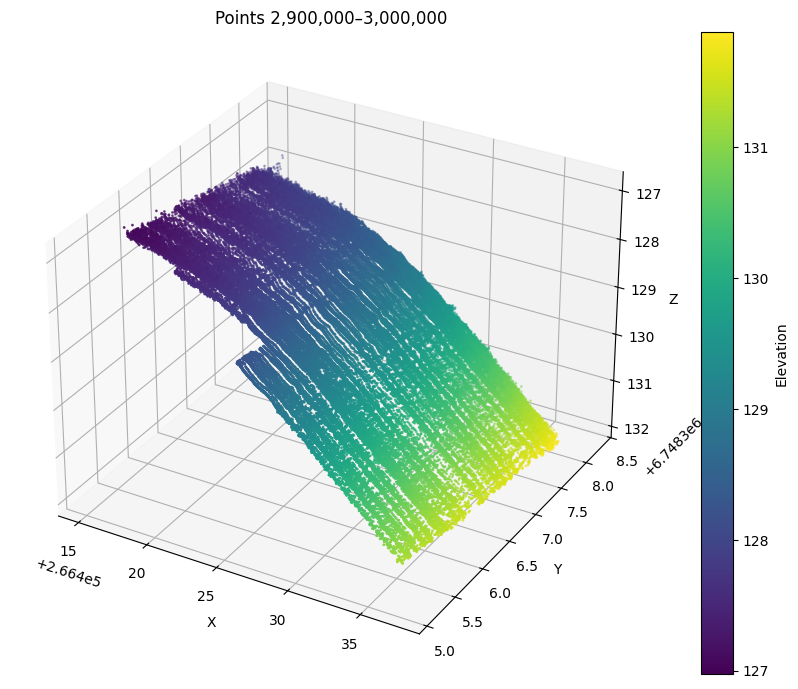

In [ ]:
start_index = 2900000
end_index = 3000000
interval_data = load_xyz_interval(data, start_index, end_index)
print(f"Loaded {interval_data.shape[0]} points from the file.")
plot_xyz(interval_data, title=f"Points {start_index:,}–{end_index:,}")

Loaded 100000 points from the file.


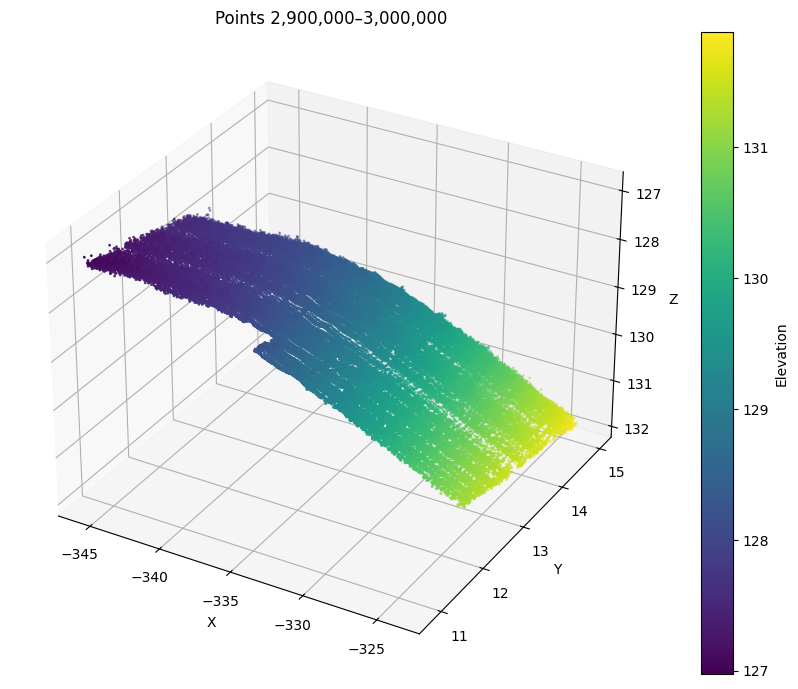

In [ ]:
interval_data = load_xyz_interval(data_local, start_index, end_index)
print(f"Loaded {interval_data.shape[0]} points from the file.")
plot_xyz(interval_data, title=f"Points {start_index:,}–{end_index:,}")

In [ ]:
# Assuming interval_data is a NumPy array of shape (N, 3)
seabed, anomalies, plane_model = advanced_seabed_processing(
    data=interval_data,
    voxel_size=0.05,
    nb_neighbors=20,
    std_ratio=2.0,
    plane_distance_threshold=0.03,
)

In [ ]:
seabed, anomalies, plane_model = advanced_seabed_processing(
    filename,
    voxel_size=0.05,
    nb_neighbors=20,
    std_ratio=2.0,
    plane_distance_threshold=0.03,
)

# Visualize: seabed in gray, anomalies in red
seabed.paint_uniform_color([0.7, 0.7, 0.7])
anomalies.paint_uniform_color([1, 0, 0])
o3d.visualization.draw_geometries([seabed, anomalies])
o3d.io.write_point_cloud("seabed_cleaned.xyz", seabed)
o3d.io.write_point_cloud("anomalies.xyz", anomalies)